In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from market_intelligence.data.market.yahoo import download_assets
df = download_assets(['SPY', 'GLD'], '2015-01-01', '2023-12-31')

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [ ]:
from market_intelligence.data.market.yahoo import align_assets
aligned = align_assets(df)

In [4]:
aligned

SPY                    GLD          
Price            Close     Volume       Close    Volume
Date                                                   
2015-01-02  169.687836  121465900  114.080002   7109600
2015-01-05  166.623322  169632600  115.800003   8177400
2015-01-06  165.053909  209151400  117.120003  11238300
2015-01-07  167.110687  125346700  116.430000   6434200
2015-01-08  170.076050  147217800  115.940002   7033700
...                ...        ...         ...       ...
2023-12-22  459.779907   67160400  190.270004   7176300
2023-12-26  461.721344   55387000  191.720001   4502700
2023-12-27  462.556152   68000300  192.589996   5813300
2023-12-28  462.730835   77158100  191.470001   6171500
2023-12-29  461.391296  122283100  191.169998   4612300

[2264 rows x 4 columns]

In [5]:
aligned['SPY']['Close']

Date
2015-01-02    169.687836
2015-01-05    166.623322
2015-01-06    165.053909
2015-01-07    167.110687
2015-01-08    170.076050
                 ...    
2023-12-22    459.779907
2023-12-26    461.721344
2023-12-27    462.556152
2023-12-28    462.730835
2023-12-29    461.391296
Name: Close, Length: 2264, dtype: float64

In [ ]:
from market_intelligence.features.market_features import calculate_returns 

returns = calculate_returns(aligned['SPY']['Close'])
returns


Date
2015-01-02         NaN
2015-01-05   -0.018060
2015-01-06   -0.009419
2015-01-07    0.012461
2015-01-08    0.017745
                ...   
2023-12-22    0.002010
2023-12-26    0.004223
2023-12-27    0.001808
2023-12-28    0.000378
2023-12-29   -0.002895
Name: Close, Length: 2264, dtype: float64

In [ ]:
from market_intelligence.market_analytics.market_summary import market_summary

market_summary(aligned['SPY'])

c:\Users\nimes.DESKTOP-L78OJ71\OneDrive\Desktop\projects\fin\market_analytics_api\analytics.py:15: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  year_high = close.last("365D").max()
c:\Users\nimes.DESKTOP-L78OJ71\OneDrive\Desktop\projects\fin\market_analytics_api\analytics.py:16: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  year_low = close.last("365D").min()


{'current_price': np.float64(461.39129638671875),
 'daily_return': np.float64(-0.0028948547903271393),
 'annual_return': np.float64(0.2617578836134973),
 'current_drawdown': np.float64(-0.0028948547903271393),
 'max_drawdown': np.float64(-0.33717274248906437),
 '52_week_high': np.float64(462.7308349609375),
 '52_week_low': np.float64(362.7570495605469),
 'annualized_volatility': np.float64(0.010771760064829895),
 'avg_volume': np.float64(90777901.98763251),
 'trend': 'Bullish'}

In [14]:
print(type(aligned['SPY']))
print(aligned['SPY'].head())

<class 'pandas.core.frame.DataFrame'>
Price            Close     Volume
Date                             
2015-01-02  169.687805  121465900
2015-01-05  166.623352  169632600
2015-01-06  165.053940  209151400
2015-01-07  167.110687  125346700
2015-01-08  170.076035  147217800


In [ ]:
from market_intelligence.features.market_features import monthly_returns
monthly_returns(aligned['SPY']['Close'])

Date
2015-01-31         NaN
2015-02-28    0.056205
2015-03-31   -0.015706
2015-04-30    0.009834
2015-05-31    0.012856
                ...   
2023-08-31   -0.016252
2023-09-30   -0.047434
2023-10-31   -0.021709
2023-11-30    0.091344
2023-12-31    0.045655
Freq: ME, Name: Close, Length: 108, dtype: float64

In [ ]:
from market_intelligence.market_analytics.market_summary import correlation_analysis
correlation_analysis(aligned)

ImportError: cannot import name 'correlation_analysis' from 'analytics' (c:\Users\nimes.DESKTOP-L78OJ71\OneDrive\Desktop\projects\fin\market_analytics_api\analytics.py)

In [13]:
returns = calculate_returns(aligned['Close'])


KeyError: 'Close'

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
from market_intelligence.data.market.yahoo import download_asset
df = download_asset(['SPY'], '2015-01-01', '2023-12-31')

[*********************100%***********************]  1 of 1 completed


In [3]:
df

Price,Close,Volume
Date,,
2015-01-02,169.687866,121465900
2015-01-05,166.623337,169632600
2015-01-06,165.053909,209151400
2015-01-07,167.110657,125346700
2015-01-08,170.076080,147217800
...,...,...
2023-12-22,459.779907,67160400
2023-12-26,461.721344,55387000
2023-12-27,462.556183,68000300


In [ ]:
from market_intelligence.models.regime.kmeans import calculate_features 
features = calculate_features(df)

In [ ]:
from market_intelligence.models.regime.kmeans import prepare_features, train_regime_model, analyze_regimes

features, scaler, prepared = prepare_features(features)
model, labels = train_regime_model(prepared)
analyze_regimes(features, labels)


,Weekly_Returns,Monthly_Returns,annualized_volatility_20,annualized_volatility_60,MA20/MA50,MA50/MA200,Current/MA200,Current Drawdown,Max Drawdown
Regime,,,,,,,,,
0,0.008508,0.040164,0.189515,0.250588,1.016502,0.975968,1.007229,-0.099129,-0.200497
1,-0.012742,-0.063003,0.327489,0.265837,0.961809,0.979616,0.916366,-0.160380,-0.192082
2,0.003549,0.015242,0.114799,0.119462,1.011610,1.056117,1.075579,-0.019678,-0.062522


c:\Users\nimes.DESKTOP-L78OJ71\OneDrive\Desktop\projects\fin\market_intelligence\market_analytics\regime.py:69: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


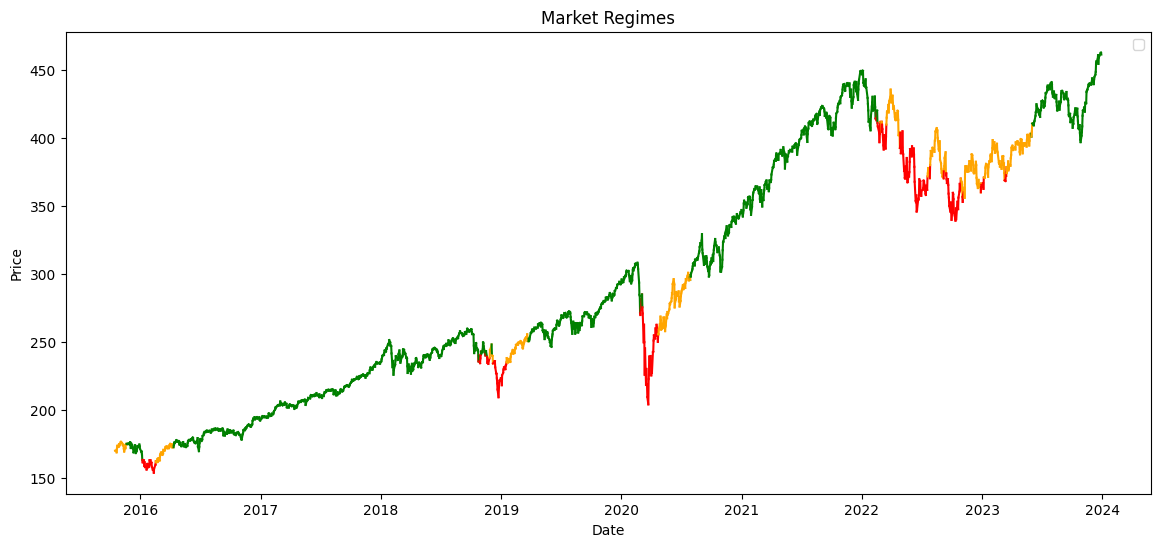

In [ ]:
from market_intelligence.models.regime.kmeans import plot_regimes
plot_regimes(df, features, labels)

In [15]:
prepared

array([[ 0.29225901,  0.24404938,  0.16037166, ..., -0.77935518,
         0.17662899, -0.22028991],
       [ 0.27298906,  0.61519565,  0.15710097, ..., -0.77215485,
         0.18448557, -0.22028991],
       [ 0.48881021,  0.47371736,  0.07386835, ..., -0.79333941,
         0.16407391, -0.22028991],
       ...,
       [ 0.03339612,  0.87385363, -0.55348968, ...,  0.94481491,
         0.82181985, -0.1888962 ],
       [ 0.64621094,  0.86020126, -0.55749218, ...,  0.9332896 ,
         0.82181985, -0.1888962 ],
       [ 0.1181966 ,  0.81128959, -0.54000247, ...,  0.86596386,
         0.7737684 , -0.1888962 ]], shape=(2065, 9))

In [ ]:
from market_intelligence.models.regime.kmeans import find_similar_periods

find_similar_periods(prepared, features)

,Similar Date,Distance
0,2023-12-27,0.157254
1,2023-12-21,0.157862
2,2023-12-26,0.160889
3,2023-12-22,0.221606
4,2023-12-20,0.500892


In [21]:
find_similar_periods(
    prepared,
    features,
    query_date="2022-06-15"
)

,Similar Date,Distance
0,2022-06-13,0.577190
1,2022-06-14,1.070465
2,2022-06-17,1.090211
3,2022-06-16,1.298368
4,2022-06-10,1.648230
